In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/abalone.csv')

In [3]:
df.head()

,M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8


In [4]:
column_names = {
    'M': 'Sex',
    '0.455': 'Length',
    '0.365': 'Diameter',
    '0.095': 'Height',
    '0.514': 'Whole_weight',
    '0.2245': 'Shucked_weight',
    '0.101': 'Viscera_weight',
    '0.15': 'Shell_weight',
    '15': 'Rings'
}

In [5]:
df = df.rename(columns=column_names)

In [6]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8


## Пояснение к данным:
    1. Sex - пол моллюска
    2. Length - длина моллюска
    3. Diameter - диаметр моллюска
    4. Height - высота моллюска
    5. Whole_weight - вес моллюска с раковиной
    6. Shucked_weight - вес моллюска без раковины
    7. Viscera_weight - вес внутренних органов моллюска
    8. Shell_weight - вес раковины
    9. Rings - вот это надо предсказать но я переведу в Age = Rings + 1.5

## ВСЯ РАБОТА

In [7]:
df['Age'] = df['Rings'] + 1.5

In [8]:
df = df.drop('Rings', axis=1)

In [9]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,8.5
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,10.5
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,11.5
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,8.5
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,9.5


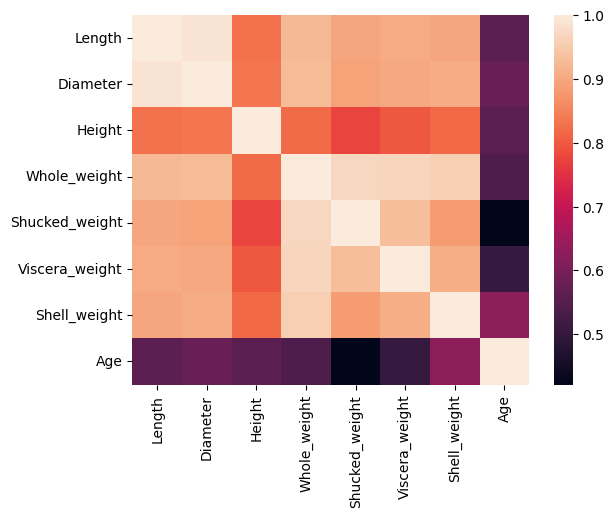

In [10]:
sns.heatmap(df.corr(numeric_only=True));

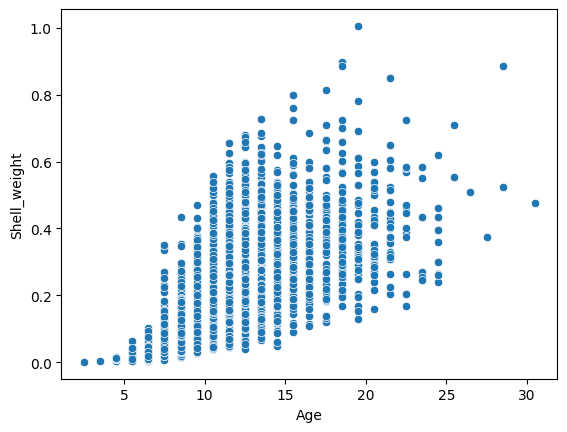

In [11]:
sns.scatterplot(x='Age', y='Shell_weight', data=df);

In [12]:
df[(df['Age'] >= 28) & (df['Shell_weight'] > 0.4)]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
479,F,0.700,0.585,0.185,1.8075,0.7055,0.3215,0.475,30.5
2107,M,0.665,0.535,0.225,2.1835,0.7535,0.3910,0.885,28.5
2208,F,0.550,0.465,0.180,1.2125,0.3245,0.2050,0.525,28.5


In [13]:
df = df.drop([479, 2107])

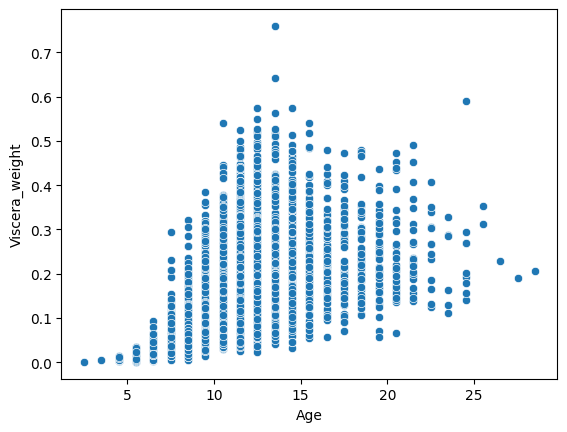

In [14]:
sns.scatterplot(x='Age', y='Viscera_weight', data=df);

In [15]:
df[(df['Age'] <= 14.5) & (df['Viscera_weight'] > 0.7)]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
1762,M,0.775,0.63,0.25,2.7795,1.3485,0.76,0.578,13.5


In [16]:
df = df.drop(1762)

In [17]:
df[(df['Age'] >= 23) & (df['Viscera_weight'] > 0.5)]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
2333,F,0.8,0.63,0.195,2.526,0.933,0.59,0.62,24.5


In [18]:
df = df.drop(2333)

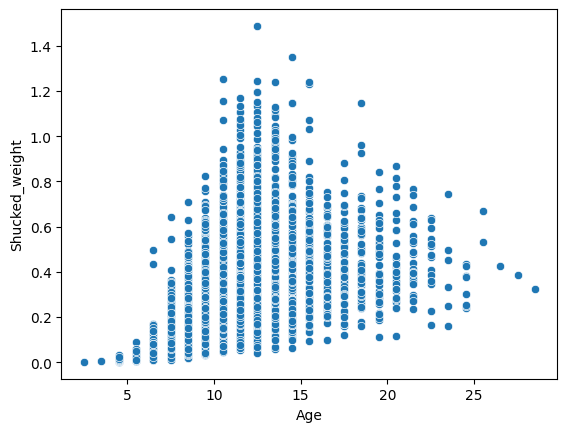

In [19]:
sns.scatterplot(x='Age', y='Shucked_weight', data=df);

In [20]:
df[(df['Shucked_weight'] >= 1.4)]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
1208,F,0.78,0.63,0.215,2.657,1.488,0.4985,0.586,12.5


In [21]:
df = df.drop(1208)

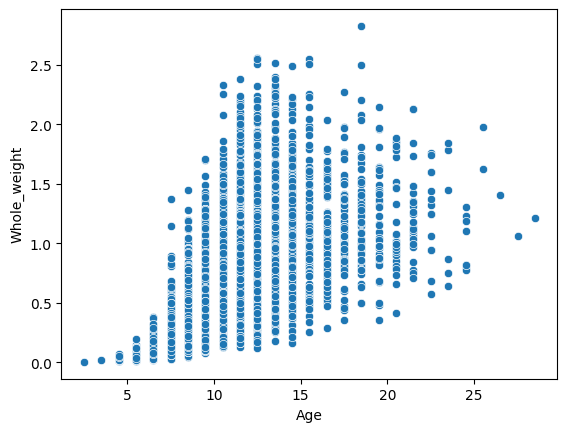

In [22]:
sns.scatterplot(x='Age', y='Whole_weight', data=df);

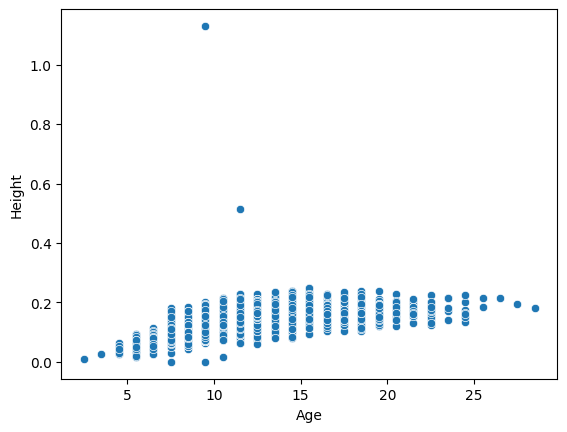

In [23]:
sns.scatterplot(x='Age', y='Height', data=df);

In [24]:
df[df['Height'] > 0.4]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
1416,M,0.705,0.565,0.515,2.210,1.1075,0.4865,0.5120,11.5
2050,F,0.455,0.355,1.130,0.594,0.3320,0.1160,0.1335,9.5


In [25]:
df[df['Height'] == 0]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Age
1256,I,0.430,0.34,0.0,0.428,0.2065,0.0860,0.1150,9.5
3995,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,7.5


In [26]:
df = df.drop([1416, 2050, 1256, 3995])

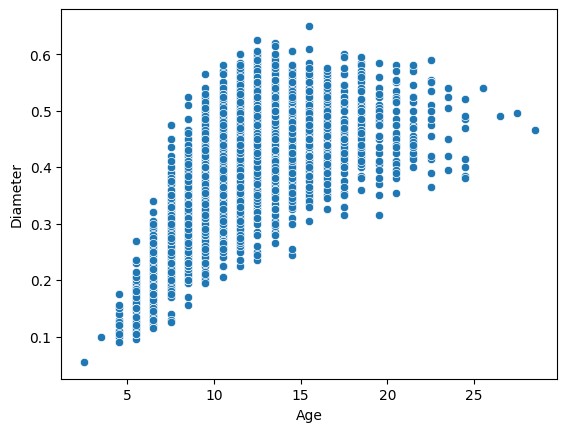

In [27]:
sns.scatterplot(x='Age', y='Diameter', data=df);

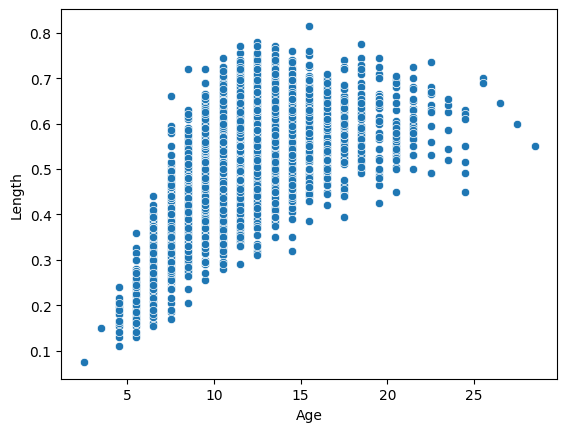

In [28]:
sns.scatterplot(x='Age', y='Length', data=df);

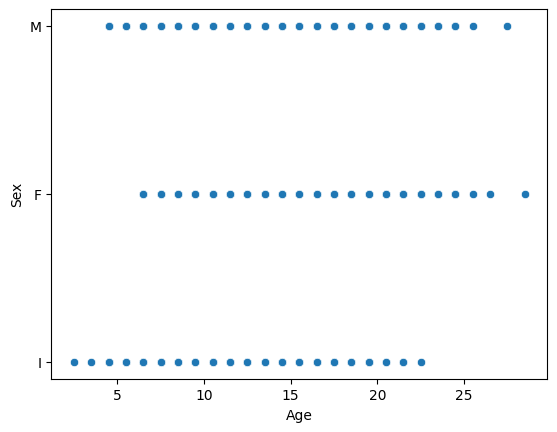

In [29]:
sns.scatterplot(x='Age', y='Sex', data=df);

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [31]:
X = df.drop('Age', axis=1)

In [32]:
y = df['Age']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [34]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [35]:
num_features

['Length',
 'Diameter',
 'Height',
 'Whole_weight',
 'Shucked_weight',
 'Viscera_weight',
 'Shell_weight']

In [36]:
cat_features

['Sex']

In [37]:
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [38]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, cat_features),
        ('num', num_transformer, num_features)
    ]
)

In [40]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7,.9, .95, .99, 1], n_jobs=-1, max_iter=1_000_000))
])

In [41]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [42]:
y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

In [43]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.0019915369573169964
Лучшее значение l1_ratio: 1.0


In [44]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [45]:
MAE

1.4776993594357328

In [46]:
MSE

4.327916840301683

In [47]:
RMSE

np.float64(2.08036459311864)

In [48]:
r2_train

0.5848761453937501

In [49]:
r2_test

0.5973348538819259

In [50]:
df['Age'].mean()

np.float64(11.421766258699304)

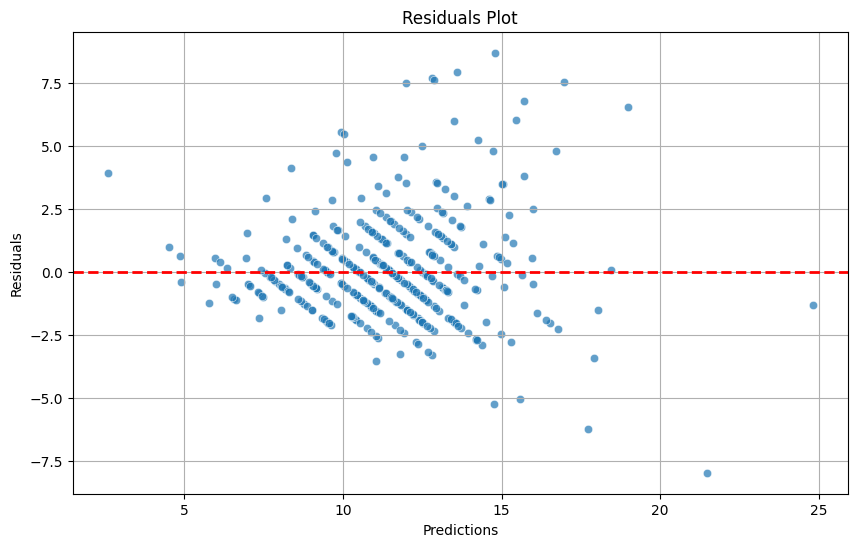

In [51]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

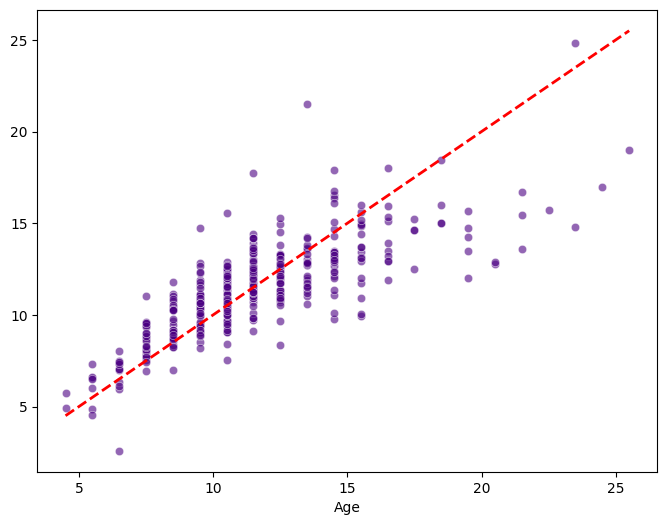

In [52]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2);

In [53]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [54]:
y_pred_full = pipe.predict(X)

In [55]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.0021458533085634123
Лучшее значение l1_ratio: 1.0


In [56]:
r2_full = r2_score(y, y_pred_full)

In [57]:
r2_full

0.5858245200895785

In [58]:
test_mollusks = pd.DataFrame(
    [
        {
            "Sex": "I",
            "Length": 0.150,
            "Diameter": 0.100,
            "Height": 0.030,
            "Whole_weight": 0.020,
            "Shucked_weight": 0.010,
            "Viscera_weight": 0.005,
            "Shell_weight": 0.005,
        },
        {
            "Sex": "M",
            "Length": 0.750,
            "Diameter": 0.600,
            "Height": 0.220,
            "Whole_weight": 2.100,
            "Shucked_weight": 0.950,
            "Viscera_weight": 0.450,
            "Shell_weight": 0.650,
        },
    ]
)

In [59]:
test_mollusks

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,I,0.15,0.1,0.03,0.02,0.01,0.005,0.005
1,M,0.75,0.6,0.22,2.10,0.95,0.450,0.650


In [60]:
predictions = pipe.predict(test_mollusks)

In [61]:
print(f"1. Предсказанный возраст младенца (Infant): {predictions[0]:.2f} лет")
print(f"2. Предсказанный возраст старого самца (Male): {predictions[1]:.2f} лет")

1. Предсказанный возраст младенца (Infant): 4.61 лет
2. Предсказанный возраст старого самца (Male): 13.10 лет


In [62]:
import json
import os

advanced_report = {
    "project": "Abalone Age Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Abalone_Age": df['Age'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [63]:
from joblib import dump, load

In [64]:
dump(pipe, 'model/abalone_age_predict_elastic_net_cv_2026_v1.pkl')

['model/abalone_age_predict_elastic_net_cv_2026_v1.pkl']

In [65]:
loaded_pipe = load('model/abalone_age_predict_elastic_net_cv_2026_v1.pkl')

In [66]:
loaded_pipe.predict(test_mollusks)

array([ 4.60816816, 13.09892759])